<a href="https://colab.research.google.com/github/carlapaz066-tech/Modelizado_de_Sistemas_de_IA/blob/main/Final_nro_2_Practica_Unidad_3_RRNN_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset de ropa
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Etiquetas de las 10 categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalización de los píxeles al rango [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [ ]:
model = models.Sequential([
    # Capa de Entrada: Aplana la imagen de 28x28 a un vector de 784
    layers.Flatten(input_shape=(28, 28)),

    # Capa densa con 128 neuronas y activación 'relu'
    layers.Dense(128, activation='relu'),

    # Capa densa con 64 neuronas y activación 'relu'
    layers.Dense(64, activation='relu'),

    # Capa de Salida: 10 neuronas con activación 'softmax'
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Mejora del MLP: Capacidad y Dropout
Optimizamos la red MLP aumentando las neuronas y añadiendo Dropout para mejorar la generalización.

In [ ]:
model_improved = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    # Aumentamos la densidad y bajamos el Dropout a 0.1 para no perder tanta información
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),

    layers.Dense(10, activation='softmax')
])

# Optimizador Adam con configuración estándar
model_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Implementación de Early Stopping monitoreando 'val_loss'
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history = model.fit(
    train_images, train_labels,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8204 - loss: 0.5103 - val_accuracy: 0.8482 - val_loss: 0.4184
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8619 - loss: 0.3790 - val_accuracy: 0.8640 - val_loss: 0.3723
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8753 - loss: 0.3395 - val_accuracy: 0.8703 - val_loss: 0.3564
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8823 - loss: 0.3168 - val_accuracy: 0.8783 - val_loss: 0.3397
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8886 - loss: 0.2990 - val_accuracy: 0.8791 - val_loss: 0.3293
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8950 - loss: 0.2821 - val_accuracy: 0.8767 - val_loss: 0.3453
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8997 - loss: 0.2696 - val_accuracy: 0.8787 - val_loss: 0.3318
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9023 - loss: 0.2588 - 

### Entrenamiento y Visualización de Métricas
Entrenamos el modelo mejorado y graficamos su progreso.

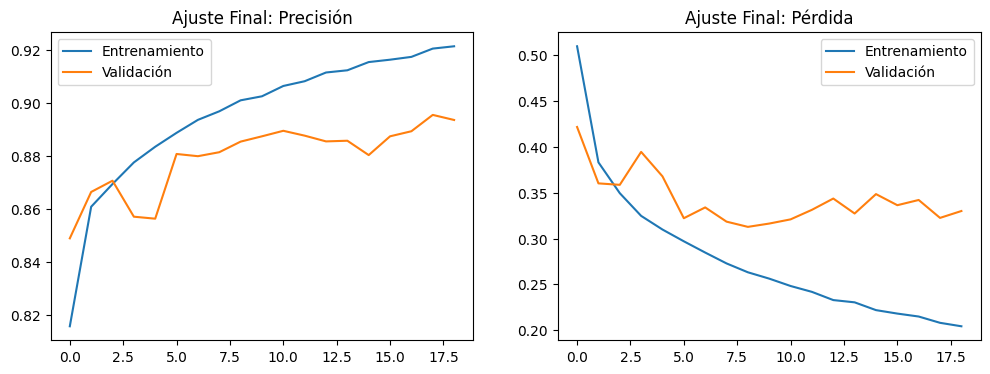

In [ ]:
# Entrenamos con un poco más de paciencia para permitir convergencia
early_stop_improved = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_images, train_labels,
    epochs=60,
    validation_split=0.2,
    callbacks=[early_stop_improved],
    verbose=0
)

# Graficar resultados del ajuste final
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Entrenamiento')
plt.plot(history_improved.history['val_accuracy'], label='Validación')
plt.title('Ajuste Final: Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Entrenamiento')
plt.plot(history_improved.history['val_loss'], label='Validación')
plt.title('Ajuste Final: Pérdida')
plt.legend()
plt.show()

## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 2ms/step - accuracy: 0.8830 - loss: 0.3363

Precisión en el set de prueba: 88.30%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


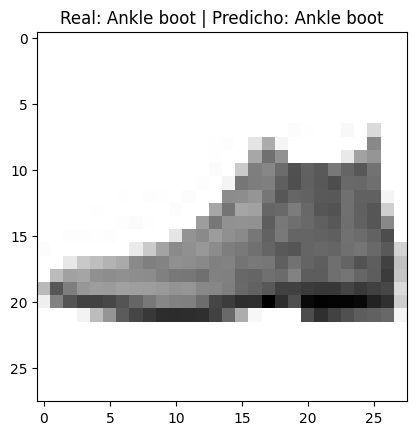

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')

# AYUDA: Realiza una predicción sobre el set de prueba
predictions = model.predict(test_images)

# Visualización de una predicción individual
n = 0 # Puedes cambiar este índice
plt.imshow(test_images[n], cmap=plt.cm.binary)
plt.title(f"Real: {class_names[test_labels[n]]} | Predicho: {class_names[np.argmax(predictions[n])]}")
plt.show()

In [ ]:
test_loss_imp, test_acc_imp = model_improved.evaluate(test_images, test_labels, verbose=0)
print(f'Precisión del MLP mejorado: {test_acc_imp:.2%}')

Precisión del MLP mejorado: 87.53%


## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .